# Mathematische und statistische Grundlagen

**Notebook 00 der Reihe *Algorithmen des Maschinellen Lernens***

Autor: Mark Baumann · Sprache: Deutsch · Kernel: Python 3

---

## Zusammenfassung

Dieses Notebook stellt das mathematische Vokabular bereit, auf dem die übrigen
Notebooks dieser Reihe aufbauen: lineare Algebra (Vektoren, Matrizen, Eigen- und
Singulärwertzerlegung), Grundbegriffe der Wahrscheinlichkeitstheorie (Erwartungswert,
Bayes-Theorem, Maximum-Likelihood-Prinzip) sowie konvexe Optimierung
(Gradientenverfahren, Konvergenzbedingungen). Jeder Abschnitt verbindet die
Herleitung mit einer lauffähigen NumPy-Demonstration, sodass abstrakte Aussagen
unmittelbar an konkreten Zahlen überprüft werden können. Das Notebook führt keine
eigenständige Fallstudie durch, sondern dient als Referenz, auf die die
Notebooks 01–08 explizit verweisen.

## Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. Vektorräume, Normen und lineare Abbildungen in NumPy korrekt umsetzen,
2. Eigenwertzerlegung und Singulärwertzerlegung (SVD) unterscheiden und ihren
   Zusammenhang benennen,
3. den Zusammenhang zwischen bedingter Wahrscheinlichkeit, Bayes-Theorem und dem
   Maximum-Likelihood-Prinzip herleiten,
4. Gradientenabstieg als iterative Lösung eines Optimierungsproblems begründen und
   seine Konvergenzbedingungen angeben,
5. den Bias-Varianz-Zerlegung des erwarteten Vorhersagefehlers formal herleiten.

## Inhalt

1. [Rechenumgebung](#1)
2. [Lineare Algebra](#2)
3. [Wahrscheinlichkeit und Statistik](#3)
4. [Konvexe Optimierung](#4)
5. [Bias-Varianz-Zerlegung](#5)
6. [Übungsaufgaben](#6)
7. [Literatur](#7)

In [1]:
from __future__ import annotations

import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

mpl.rcParams.update(
    {
        "figure.figsize": (7.0, 4.5),
        "figure.dpi": 110,
        "font.size": 10,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.3,
        "legend.frameon": False,
    }
)
np.set_printoptions(precision=4, suppress=True)

print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}")

Python 3.11.15, NumPy 2.4.6


<a id="2"></a>
## 2 Lineare Algebra

### 2.1 Vektoren, Normen, Skalarprodukt

Für $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$ ist das Skalarprodukt
$\langle \mathbf{u}, \mathbf{v}\rangle = \sum_i u_i v_i = \mathbf{u}^\top\mathbf{v}$
und die euklidische ($\ell_2$-)Norm $\lVert\mathbf{u}\rVert_2 = \sqrt{\langle\mathbf{u},\mathbf{u}\rangle}$.
Der Winkel zwischen zwei Vektoren ergibt sich aus
$\cos\theta = \langle\mathbf{u},\mathbf{v}\rangle / (\lVert\mathbf{u}\rVert_2\lVert\mathbf{v}\rVert_2)$.
Diese Größen sind die Grundlage der euklidischen Distanz in k-NN (Notebook 03) und der
Kosinus-Ähnlichkeit in Naive Bayes für Text (Notebook 05).

In [2]:
u = np.array([3.0, 4.0])
v = np.array([1.0, 2.0])

dot = u @ v
norm_u, norm_v = np.linalg.norm(u), np.linalg.norm(v)
cos_theta = dot / (norm_u * norm_v)

print(f"<u, v>          = {dot:.4f}")
print(f"||u||_2         = {norm_u:.4f}")
print(f"||v||_2         = {norm_v:.4f}")
print(f"Winkel(u, v)    = {np.degrees(np.arccos(cos_theta)):.2f} Grad")
print(f"euklid. Distanz = {np.linalg.norm(u - v):.4f}")
print(f"Manhattan-Dist. = {np.sum(np.abs(u - v)):.4f}")

<u, v>          = 11.0000
||u||_2         = 5.0000
||v||_2         = 2.2361
Winkel(u, v)    = 10.30 Grad
euklid. Distanz = 2.8284
Manhattan-Dist. = 4.0000


### 2.2 Matrizen als lineare Abbildungen

Eine Matrix $A \in \mathbb{R}^{m\times n}$ bildet $\mathbb{R}^n \to \mathbb{R}^m$ linear
ab. Zentrale Kenngrößen: **Rang** (Dimension des Bildraums), **Spur**
$\operatorname{tr}(A) = \sum_i A_{ii}$, **Determinante** (Volumenskalierung bei
quadratischem $A$) und die **Konditionszahl** $\kappa(A) = \sigma_{\max}/\sigma_{\min}$,
die die Empfindlichkeit von $Ax=b$ gegenüber Störungen in $b$ misst. Notebook 01
(Abschnitt 6.5) nutzt $\kappa$, um zu begründen, warum man $X^\top X$ nicht explizit
invertiert.

In [3]:
A = np.array([[2.0, 1.0], [1.0, 3.0]])

print("A =\n", A)
print(f"\nRang(A)        = {np.linalg.matrix_rank(A)}")
print(f"Spur(A)        = {np.trace(A):.4f}")
print(f"det(A)         = {np.linalg.det(A):.4f}")
print(f"Konditionszahl = {np.linalg.cond(A):.4f}")

A =
 [[2. 1.]
 [1. 3.]]

Rang(A)        = 2
Spur(A)        = 5.0000
det(A)         = 5.0000
Konditionszahl = 2.6180


### 2.3 Eigenwertzerlegung

Für eine quadratische, symmetrische Matrix $A$ existieren orthogonale Eigenvektoren
$\mathbf{q}_i$ und reelle Eigenwerte $\lambda_i$ mit

$$
A\mathbf{q}_i = \lambda_i \mathbf{q}_i, \qquad A = Q\Lambda Q^\top,
$$

wobei $Q$ die Eigenvektoren als Spalten und $\Lambda = \operatorname{diag}(\lambda_i)$
enthält. Für die empirische Kovarianzmatrix $\Sigma$ eines Datensatzes sind die
Eigenvektoren die Hauptachsen der Datenwolke und die Eigenwerte die Varianz entlang
dieser Achsen — die Grundlage der Hauptkomponentenanalyse (Notebook 07).

In [4]:
eigvals, eigvecs = np.linalg.eigh(A)  # eigh: fuer symmetrische Matrizen, sortiert aufsteigend

print(f"Eigenwerte  lambda = {eigvals}")
print("Eigenvektoren (Spalten):\n", eigvecs)

# Rekonstruktion A = Q Lambda Q^T pruefen
reconstructed = eigvecs @ np.diag(eigvals) @ eigvecs.T
print(f"\nmax. Rekonstruktionsfehler ||A - Q Lambda Q^T|| = "
      f"{np.abs(A - reconstructed).max():.2e}")

Eigenwerte  lambda = [1.382 3.618]
Eigenvektoren (Spalten):
 [[-0.8507  0.5257]
 [ 0.5257  0.8507]]

max. Rekonstruktionsfehler ||A - Q Lambda Q^T|| = 6.66e-16


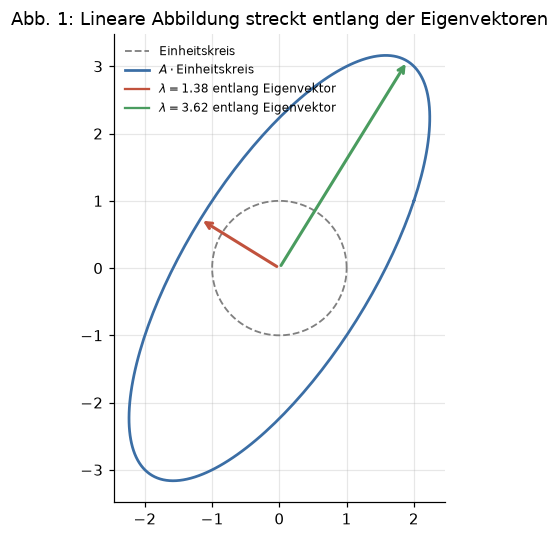

In [5]:
fig, ax = plt.subplots(figsize=(5.0, 5.0))
theta = np.linspace(0, 2 * np.pi, 200)
circle = np.stack([np.cos(theta), np.sin(theta)])
ellipse = A @ circle

ax.plot(*circle, "--", color="gray", lw=1.2, label="Einheitskreis")
ax.plot(*ellipse, color="#3b6ea5", lw=1.8, label=r"$A \cdot \mathrm{Einheitskreis}$")
for val, vec, color in zip(eigvals, eigvecs.T, ["#c1523d", "#4a9c5f"]):
    ax.annotate(
        "", xy=vec * val, xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=color, lw=2),
    )
    ax.plot([], [], color=color, label=rf"$\lambda={val:.2f}$ entlang Eigenvektor")
ax.set_aspect("equal")
ax.set_title("Abb. 1: Lineare Abbildung streckt entlang der Eigenvektoren")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation.** Der Einheitskreis wird durch $A$ zu einer Ellipse verzerrt, deren
Hauptachsen exakt in Richtung der Eigenvektoren liegen; die jeweilige Halbachsenlänge
entspricht dem zugehörigen Eigenwert. Diese geometrische Lesart überträgt sich direkt
auf die PCA: Die Kovarianzellipse einer Punktwolke hat ihre Achsen in Richtung der
Eigenvektoren von $\Sigma$.

### 2.4 Singulärwertzerlegung (SVD)

Die SVD verallgemeinert die Eigenwertzerlegung auf beliebige, auch nicht-quadratische
Matrizen $X \in \mathbb{R}^{n\times p}$:

$$
X = U\Sigma V^\top,
$$

mit orthogonalen $U \in \mathbb{R}^{n\times n}$, $V \in \mathbb{R}^{p\times p}$ und
diagonalem $\Sigma$ mit nicht-negativen Singulärwerten $\sigma_1 \ge \dots \ge 0$. Es
gilt $X^\top X = V\Sigma^2 V^\top$ — die rechten Singulärvektoren von $X$ sind also die
Eigenvektoren von $X^\top X$, und $\sigma_i^2 = \lambda_i(X^\top X)$. Diese Identität ist
der Grund, warum PCA äquivalent über die Eigenzerlegung der Kovarianzmatrix *oder* über
die SVD der zentrierten Datenmatrix berechnet werden kann (Notebook 07, Abschnitt 5.2);
die SVD ist numerisch vorzuziehen, da sie $X^\top X$ nicht explizit bildet.

In [6]:
X_demo = rng.normal(size=(200, 2)) @ np.array([[2.0, 0.0], [0.3, 0.7]]).T

U, S, Vt = np.linalg.svd(X_demo - X_demo.mean(axis=0), full_matrices=False)
cov = np.cov(X_demo, rowvar=False)
eigvals_cov, eigvecs_cov = np.linalg.eigh(cov)

print("Singulaerwerte^2 / (n-1)     =", (S**2) / (len(X_demo) - 1))
print("Eigenwerte der Kovarianzmatrix =", np.sort(eigvals_cov)[::-1])
print("\n-> beide Wege liefern (bis auf Sortierung/Vorzeichen) dieselben Varianzen.")

Singulaerwerte^2 / (n-1)     = [4.0355 0.3971]
Eigenwerte der Kovarianzmatrix = [4.0355 0.3971]

-> beide Wege liefern (bis auf Sortierung/Vorzeichen) dieselben Varianzen.


<a id="3"></a>
## 3 Wahrscheinlichkeit und Statistik

### 3.1 Bedingte Wahrscheinlichkeit und Bayes-Theorem

Für Ereignisse $A, B$ mit $P(B) > 0$ ist die bedingte Wahrscheinlichkeit
$P(A\mid B) = P(A\cap B)/P(B)$. Aus der Symmetrie
$P(A\cap B) = P(A\mid B)P(B) = P(B\mid A)P(A)$ folgt unmittelbar das **Bayes-Theorem**:

$$
P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)} .
$$

In der Klassifikation mit Klassen $C_k$ und Merkmalen $\mathbf{x}$ wird daraus

$$
\underbrace{P(C_k \mid \mathbf{x})}_{\text{Posteriori}}
  \;\propto\; \underbrace{P(\mathbf{x} \mid C_k)}_{\text{Likelihood}}
              \underbrace{P(C_k)}_{\text{Priori}} ,
$$

da $P(\mathbf{x})$ nicht von $k$ abhängt und daher nur zur Normierung dient. Diese
Zerlegung ist das Fundament von Naive Bayes (Notebook 05).

In [7]:
# Klassisches Beispiel: medizinischer Test.
# Praevalenz, Sensitivitaet und Spezifitaet als Priori bzw. Likelihood.
p_krank = 0.01                 # P(Krankheit)      -- Priori
p_pos_gegeben_krank = 0.95     # P(Test+ | krank)  -- Sensitivitaet
p_pos_gegeben_gesund = 0.05    # P(Test+ | gesund) -- 1 - Spezifitaet

p_pos = (
    p_pos_gegeben_krank * p_krank
    + p_pos_gegeben_gesund * (1 - p_krank)
)
p_krank_gegeben_pos = (p_pos_gegeben_krank * p_krank) / p_pos

print(f"P(krank)            = {p_krank:.4f}")
print(f"P(Test+)             = {p_pos:.4f}")
print(f"P(krank | Test+)     = {p_krank_gegeben_pos:.4f}")
print("\n-> trotz eines positiven Tests liegt die Wahrscheinlichkeit, tatsaechlich")
print("   krank zu sein, wegen der niedrigen Praevalenz nur bei rund "
      f"{p_krank_gegeben_pos:.0%}.")

P(krank)            = 0.0100
P(Test+)             = 0.0590
P(krank | Test+)     = 0.1610

-> trotz eines positiven Tests liegt die Wahrscheinlichkeit, tatsaechlich
   krank zu sein, wegen der niedrigen Praevalenz nur bei rund 16%.


### 3.2 Maximum-Likelihood-Prinzip

Für ein Modell mit Parametern $\boldsymbol\theta$ und unabhängig identisch verteilten
(i.i.d.) Beobachtungen $y_1,\dots,y_n$ ist die Likelihood

$$
L(\boldsymbol\theta) = \prod_{i=1}^n p(y_i \mid \boldsymbol\theta),
$$

und der Maximum-Likelihood-Schätzer maximiert $L$ bzw. äquivalent die numerisch
stabilere Log-Likelihood $\ell(\boldsymbol\theta) = \sum_i \log p(y_i\mid\boldsymbol\theta)$.
Für normalverteilte Fehler ist die Maximierung der Log-Likelihood **äquivalent** zur
Minimierung der Residuenquadratsumme — der Kleinste-Quadrate-Schätzer aus Notebook 01
ist also ein Spezialfall des MLE-Prinzips. Für binäre Zielgrößen (Bernoulli-verteilt)
führt dasselbe Prinzip auf die Kreuzentropie-Verlustfunktion der logistischen
Regression (Notebook 02).

In [8]:
# Empirische Illustration: MLE der Normalverteilung ist Mittelwert und (biased) Varianz.
true_mu, true_sigma = 5.0, 2.0
sample = rng.normal(true_mu, true_sigma, size=500)


def neg_log_likelihood(params: np.ndarray, data: np.ndarray) -> float:
    mu, log_sigma = params
    sigma = np.exp(log_sigma)  # Reparametrisierung sichert sigma > 0
    return -np.sum(stats.norm.logpdf(data, loc=mu, scale=sigma))


from scipy.optimize import minimize

result = minimize(neg_log_likelihood, x0=[0.0, 0.0], args=(sample,), method="Nelder-Mead")
mu_mle, sigma_mle = result.x[0], np.exp(result.x[1])

print(f"MLE (numerisch):    mu = {mu_mle:.4f}, sigma = {sigma_mle:.4f}")
print(f"geschlossene Form:  mu = {sample.mean():.4f}, sigma = {sample.std():.4f}")
print(f"wahre Parameter:    mu = {true_mu:.4f}, sigma = {true_sigma:.4f}")

MLE (numerisch):    mu = 4.8504, sigma = 2.0264
geschlossene Form:  mu = 4.8504, sigma = 2.0264
wahre Parameter:    mu = 5.0000, sigma = 2.0000


**Interpretation.** Die numerische Optimierung der Log-Likelihood liefert bis auf
Rundungsfehler dieselben Schätzer wie die bekannten geschlossenen Formeln
$\hat\mu=\bar y$, $\hat\sigma=\sqrt{\tfrac1n\sum(y_i-\bar y)^2}$. Das Prinzip ist jedoch
allgemeiner: Sobald keine geschlossene Form existiert (z.\,B. bei logistischer
Regression), liefert dasselbe Vorgehen — Log-Likelihood aufstellen, numerisch
optimieren — den Schätzer.

<a id="4"></a>
## 4 Konvexe Optimierung

### 4.1 Konvexität

Eine Funktion $f:\mathbb{R}^p\to\mathbb{R}$ heißt **konvex**, wenn für alle
$\mathbf{x},\mathbf{y}$ und $t\in[0,1]$

$$
f(t\mathbf{x} + (1-t)\mathbf{y}) \le t\,f(\mathbf{x}) + (1-t)\,f(\mathbf{y})
$$

gilt. Für zweifach differenzierbares $f$ ist dies äquivalent zu einer positiv
semidefiniten Hesse-Matrix $\nabla^2 f \succeq 0$. Konvexität ist algorithmisch
entscheidend: Jeder stationäre Punkt ($\nabla f = \mathbf{0}$) ist dann ein
**globales** Minimum. Sowohl der quadratische Verlust der linearen Regression
(Notebook 01) als auch die Kreuzentropie der logistischen Regression (Notebook 02)
sind konvex in ihren Parametern.

### 4.2 Gradientenabstieg

Für konvexes, differenzierbares $f$ konvergiert die Iteration

$$
\mathbf{x}^{(t+1)} = \mathbf{x}^{(t)} - \eta \nabla f(\mathbf{x}^{(t)})
$$

für $0 < \eta < 2/L$ gegen das globale Minimum, wobei $L$ eine Lipschitz-Konstante des
Gradienten ist (bei quadratischem $f$ mit Hesse-Matrix $H$: $L = \lambda_{\max}(H)$).
Zu kleines $\eta$ führt zu langsamer Konvergenz, zu großes $\eta$ zu Divergenz — dieselbe
Abwägung, die in Notebook 01, Abschnitt 6.3 empirisch gezeigt wird.

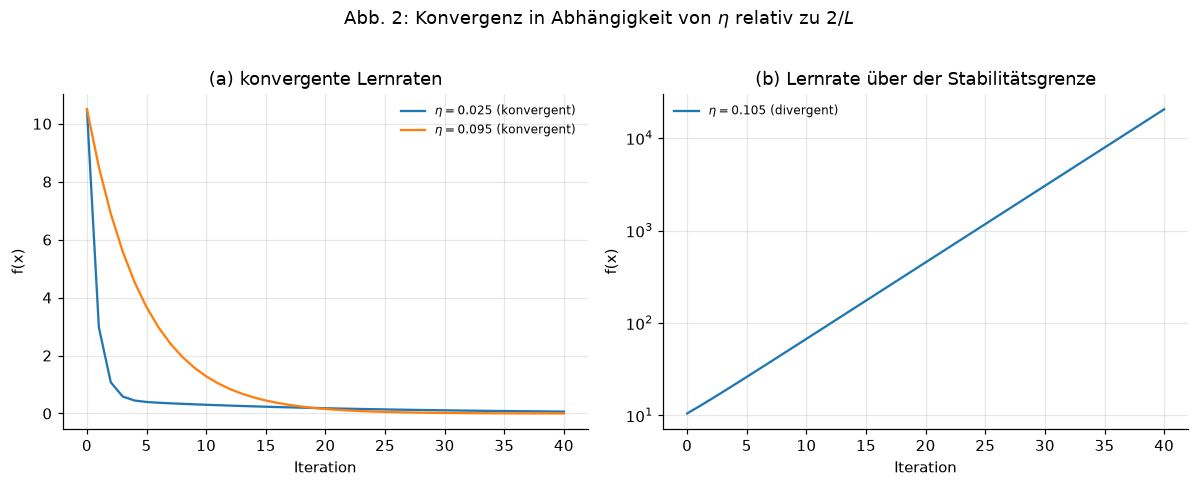

In [9]:
def f(x: np.ndarray) -> float:
    # f(x) = 0.5 x^T H x, H hat Eigenwerte 1 und 20 -> schlecht konditioniertes Problem
    H = np.array([[20.0, 0.0], [0.0, 1.0]])
    return float(0.5 * x @ H @ x)


def grad_f(x: np.ndarray) -> np.ndarray:
    H = np.array([[20.0, 0.0], [0.0, 1.0]])
    return H @ x


L = 20.0  # groesster Eigenwert von H
x0 = np.array([1.0, 1.0])
n_steps = 40

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))
for eta, style, ax_idx in [(0.5 / L, "-", 0), (1.9 / L, "-", 0), (2.1 / L, "--", 1)]:
    x = x0.copy()
    losses = [f(x)]
    for _ in range(n_steps):
        x = x - eta * grad_f(x)
        losses.append(f(x))
    axes[ax_idx].plot(losses, label=rf"$\eta = {eta:.3f}$ ({'konvergent' if ax_idx==0 else 'divergent'})")

for ax, title in zip(axes, ["(a) konvergente Lernraten", "(b) Lernrate über der Stabilitätsgrenze"]):
    ax.set_xlabel("Iteration")
    ax.set_ylabel("f(x)")
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[1].set_yscale("symlog")
fig.suptitle(r"Abb. 2: Konvergenz in Abhängigkeit von $\eta$ relativ zu $2/L$", y=1.02)
plt.tight_layout()
plt.show()

**Interpretation.** Für $\eta < 2/L$ fällt $f(\mathbf{x}^{(t)})$ monoton gegen null; bei
$\eta$ knapp unterhalb der Grenze oszilliert die Konvergenz sichtbar, bleibt aber
stabil. Überschreitet $\eta$ die Grenze $2/L$, wächst $f$ unbeschränkt — das Verfahren
divergiert. Die Konstante $L$ hängt hier von der Kondition der Hesse-Matrix ab: Je
schlechter konditioniert das Problem (großes $\lambda_{\max}/\lambda_{\min}$), desto
kleiner muss $\eta$ gewählt werden, und desto langsamer wird die Konvergenz in der
Richtung des kleinsten Eigenwerts. Dies motiviert die Standardisierung der Merkmale vor
dem Training (Notebooks 01, 02, 08).

<a id="5"></a>
## 5 Bias-Varianz-Zerlegung

Für ein Regressionsmodell $\hat f$, geschätzt auf einer zufälligen Trainingsmenge, und
einen festen Testpunkt $\mathbf{x}_0$ mit $y_0 = f(\mathbf{x}_0) + \varepsilon$,
$\mathbb{E}[\varepsilon]=0$, $\operatorname{Var}(\varepsilon)=\sigma^2$, zerlegt sich der
erwartete quadratische Testfehler (Erwartung über zufällige Trainingsmengen) als

$$
\mathbb{E}\bigl[(y_0 - \hat f(\mathbf{x}_0))^2\bigr]
  = \underbrace{\bigl(f(\mathbf{x}_0) - \mathbb{E}[\hat f(\mathbf{x}_0)]\bigr)^2}_{\text{Bias}^2}
  + \underbrace{\operatorname{Var}\bigl(\hat f(\mathbf{x}_0)\bigr)}_{\text{Varianz}}
  + \underbrace{\sigma^2}_{\text{irreduzibler Fehler}} .
$$

Flexible Modelle (tiefe Entscheidungsbäume, k-NN mit kleinem $k$) haben typischerweise
niedrigen Bias und hohe Varianz; einfache Modelle (lineare Regression, k-NN mit großem
$k$) haben hohen Bias und niedrige Varianz. Diese Zerlegung ist der theoretische
Hintergrund für die in den Notebooks 03 und 04 empirisch gezeigten
Über-/Unteranpassungs-Phänomene.

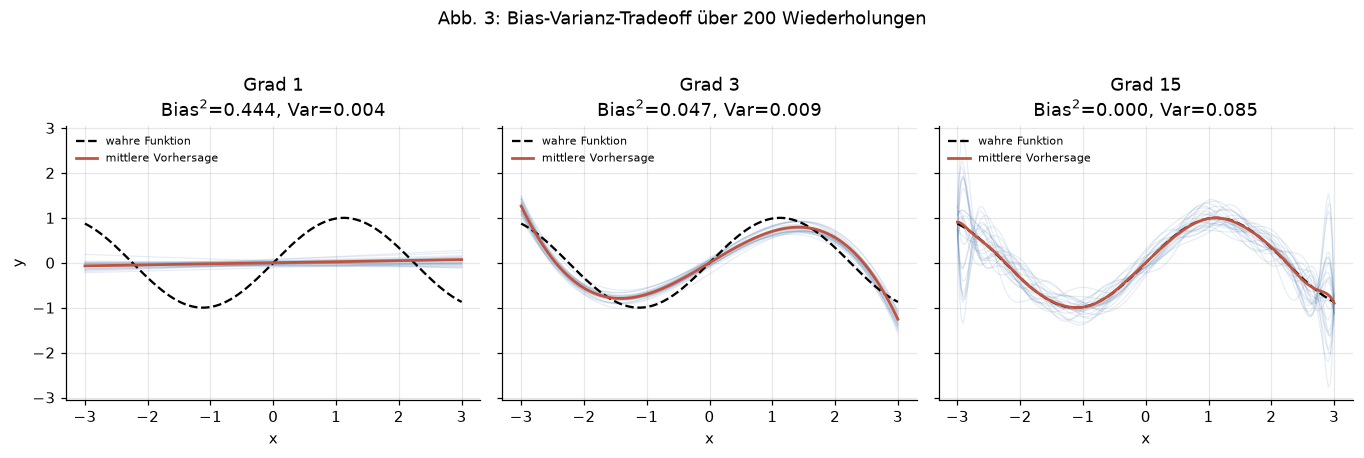

In [10]:
# Empirische Demonstration: Polynom-Fits steigenden Grades auf wiederholten Stichproben.
def true_function(x: np.ndarray) -> np.ndarray:
    return np.sin(1.4 * x)


def sample_dataset(generator: np.random.Generator, n: int = 25, sigma: float = 0.25):
    x = np.linspace(-3.0, 3.0, n)
    y = true_function(x) + generator.normal(0.0, sigma, size=n)
    return x, y


x_eval = np.linspace(-3.0, 3.0, 200)
degrees = [1, 3, 15]
n_repeats = 200

fig, axes = plt.subplots(1, len(degrees), figsize=(12.5, 4.0), sharey=True)
bias2_list, var_list = [], []

for degree, ax in zip(degrees, axes):
    predictions = np.zeros((n_repeats, len(x_eval)))
    for rep in range(n_repeats):
        gen = np.random.default_rng(1000 + rep)
        x_train, y_train_ds = sample_dataset(gen)
        coeffs = np.polyfit(x_train, y_train_ds, deg=degree)
        predictions[rep] = np.polyval(coeffs, x_eval)
        if rep < 25:
            ax.plot(x_eval, predictions[rep], color="#3b6ea5", alpha=0.12, lw=0.8)

    mean_pred = predictions.mean(axis=0)
    bias2 = np.mean((true_function(x_eval) - mean_pred) ** 2)
    variance = np.mean(predictions.var(axis=0))
    bias2_list.append(bias2)
    var_list.append(variance)

    ax.plot(x_eval, true_function(x_eval), "k--", lw=1.5, label="wahre Funktion")
    ax.plot(x_eval, mean_pred, color="#c1523d", lw=1.8, label="mittlere Vorhersage")
    ax.set_title(f"Grad {degree}\n" rf"Bias$^2$={bias2:.3f}, Var={variance:.3f}")
    ax.set_xlabel("x")
    ax.legend(fontsize=7, loc="upper left")

axes[0].set_ylabel("y")
fig.suptitle(f"Abb. 3: Bias-Varianz-Tradeoff über {n_repeats} Wiederholungen", y=1.03)
plt.tight_layout()
plt.show()

**Interpretation.** Bei Grad 1 (zu einfach) liegen alle gefitteten Kurven eng
beieinander (niedrige Varianz), verfehlen aber systematisch die gekrümmte wahre
Funktion (hoher Bias). Bei Grad 15 (zu flexibel) passt sich jede Kurve dem Rauschen
der jeweiligen Stichprobe an — die Kurvenschar streut stark (hohe Varianz), im Mittel
aber nahe der wahren Funktion (niedriger Bias). Grad 3 liegt dazwischen. Dieser
Kompromiss ist unabhängig vom konkreten Modelltyp; er tritt in identischer Form bei
$k$ in k-NN, `max_depth` bei Entscheidungsbäumen und der Netzwerkarchitektur in
Notebook 08 auf.

<a id="6"></a>
## 6 Übungsaufgaben

1. **Konditionszahl.** Berechnen Sie $\kappa(A)$ für
   $A = \begin{pmatrix}1 & 0\\0 & \epsilon\end{pmatrix}$ für $\epsilon \to 0$ und
   erklären Sie den Zusammenhang zu Notebook 01, Abschnitt 6.5.
2. **Bayes-Theorem.** Verändern Sie im medizinischen Testbeispiel die Prävalenz auf
   $10\,\%$ und $50\,\%$. Wie verändert sich $P(\text{krank}\mid\text{Test+})$, und
   warum wirkt sich eine niedrige Prävalenz so stark aus?
3. **MLE für Bernoulli.** Leiten Sie den Maximum-Likelihood-Schätzer für den Parameter
   $p$ einer Bernoulli-Verteilung aus $n$ i.i.d. Beobachtungen analytisch her und
   vergleichen Sie ihn numerisch (analog zur Normalverteilung oben) mit
   `scipy.optimize.minimize`.
4. **Stabilitätsgrenze.** Bestimmen Sie für $H = \operatorname{diag}(1, 100)$ die
   exakte Grenze $2/L$ und verifizieren Sie experimentell, dass $\eta$ knapp darüber
   zu Divergenz führt.
5. **Bias-Varianz mit mehr Rauschen.** Wiederholen Sie die Simulation aus Abschnitt 5
   mit $\sigma=1.0$ statt $0.25$. Wie verändert sich die optimale Modellkomplexität?

<a id="7"></a>
## 7 Literatur

* Golub, G. H., & Van Loan, C. F. (2013). *Matrix Computations* (4. Aufl.). Johns
  Hopkins University Press.
* Casella, G., & Berger, R. L. (2002). *Statistical Inference* (2. Aufl.). Duxbury.
* Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University
  Press.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical
  Learning* (2. Aufl.). Springer. Kap. 2 und 7.